# Location Basis — Calibration (Step 04)

**Within-county density relativity** — given a county's per-customer outage rate, is THIS location
above, at, or below its county average? A **mean-1, exposure-weighted, monotone, capped frequency
relativity** keyed on rurality (rural > 1, urban < 1), composed on the **per-customer** base:

```
λ_location(T) = λ_county(T) × customer_impact × location_basis    ← this layer
```

It is a **basis-risk correction** (*where you are*) — **not** a forward/hazard model, **not** the
live trigger.

**This notebook is the LOCAL CALIBRATION.** It reproduces the relativity from source, then adds the
NLCD **zonal-impervious commercial-core guardrail** (the *Manhattan-reads-rural* fix). It is the
piece we re-run when new PowerOutage.US data arrives:

> **forward-update process:** new data → re-run this notebook → **swap the numbers artifact** in
> `notebooks/outputs/location_basis/` → the dashboard (which only does the arithmetic) keeps working
> unchanged. **No calibration logic ever lives in the dashboard.**

**Lane discipline:** FREQUENCY only (how often a location crosses the threshold). NOT duration, NOT
severity, NOT utility identity — those are the grid/forward lane. **Conservation** (mean-1 within
county) is what keeps this from double-counting the county baseline beneath it.

**Status:** shadow / `validated:false` — *not* wired into the quoted premium. Calibrated on the PoUS
**CT/MA/RI** pilot (Jan–Mar 2019, one quiet season); national is descriptive + extrapolated. The
out-of-region + storm-season **activation gate is documented (§07), not cleared here.**

---
**Overview & method:** [`location_basis_methodology.md`](../../docs/methodology/04_location_basis/location_basis_methodology.md) ·
[`fundamentals`](../../docs/methodology/04_location_basis/location_basis_fundamentals.md) ·
[`derivation`](../../docs/methodology/04_location_basis/location_relativity_factor_derivation.md) ·
**Plan:** [`location_basis_notebook_plan.md`](../../docs/plan/04_location_basis/location_basis_notebook_plan.md) ·
**Assumptions:** LB-1 (conservation) · LB-2 (ALAND) · LB-3 (within-county) · LB-4 (tract≠premise)

## §01 · Reproduce the within-county relative target  (mean-1, exposure-weighted)

The **target** is the empirical thing the relativity is fit against: each PoUS city×utility cell's
per-customer qualifying-outage rate, normalized by its **county exposure-weighted mean**, so it is
**mean-1 within every county** (assumption **LB-1**). Built by
[`within_county_relative_rate.py`](../../docs/extra/poweroutage_us/analysis/within_county_relative_rate.py);
here we load that output and **reproduce its load-bearing property — conservation — as a correctness
check** (*not* a robustness study; we add no noise-floor / credibility work, per plan **D4**).

**Variables** (interpret-every-variable):
- `rel_A_T{T}` — the **target**: a cell's per-customer rate at threshold T ÷ its county exposure-weighted mean. `1.0` = county average; `>1` worse; `<1` better.
- `tracked` — customers tracked in the cell = the **exposure weight**.
- `cells_in_county` — sub-units per county (need ≥2 for a within-county relative).
- `A` (vs `B`) — frequency-style metric (sum of customer-share over qualifying events); the calibration uses `A`.

In [1]:
from pathlib import Path
import json, io
import numpy as np, pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'price_engine').exists())
TARGET = ROOT / 'docs/extra/poweroutage_us/analysis/outputs/within_county_relative_rate.csv'
OUT = ROOT / 'notebooks/outputs/location_basis'; OUT.mkdir(parents=True, exist_ok=True)
T_HOURS = [1, 2, 4, 8]

cells = pd.read_csv(TARGET)
n_counties = cells.groupby(['state', 'county']).ngroups
print(f"sample-flow: {len(cells)} city×utility cells | {n_counties} counties | "
      f"states {sorted(cells.state.unique())} | PoUS CT/MA/RI, Jan–Mar 2019")
print(f"dropped from within-county stats: cells_in_county < 2 → "
      f"{int((cells['cells_in_county'] < 2).sum())} cells (no within-county relative possible)\n")

def exp_wtd_quantile(v, w, q):
    o = np.argsort(v); v, w = np.asarray(v)[o], np.asarray(w)[o]
    cw = (np.cumsum(w) - 0.5 * w) / w.sum()
    return float(np.interp(q, cw, v))

rows = []
for T in T_HOURS:
    col = f'rel_A_T{T}'
    sub = cells[(cells['cells_in_county'] >= 2) & cells[col].notna()].copy()
    sub['wx'] = sub[col] * sub['tracked']
    g = sub.groupby(['state', 'county'])
    cmean = g['wx'].sum() / g['tracked'].sum()          # per-county exposure-weighted mean of the relative
    rows.append({'T_h': T, 'n_cells': len(sub), 'n_counties': g.ngroups,
                 'county_mean_median': round(float(cmean.median()), 4),
                 'rel_p50': round(exp_wtd_quantile(sub[col], sub['tracked'], 0.5), 2),
                 'rel_p90': round(exp_wtd_quantile(sub[col], sub['tracked'], 0.9), 2)})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

assert (summary['county_mean_median'] - 1.0).abs().max() < 0.05, "CONSERVATION BROKEN (LB-1)!"
print("\n✓ conservation holds — per-county exposure-weighted mean ≈ 1.0 (LB-1 preserved).")
print("  reading: p50 < 1 with p90 > 1 ⇒ most customers sit at/below their county average and a")
print("  thin rural tail carries the excess — location basis is a REDISTRIBUTION, not a level shift.")
summary.to_csv(OUT / 'target_summary.csv', index=False)

sample-flow: 475 city×utility cells | 28 counties | states ['Connecticut', 'Massachusetts', 'Rhode Island'] | PoUS CT/MA/RI, Jan–Mar 2019
dropped from within-county stats: cells_in_county < 2 → 2 cells (no within-county relative possible)

 T_h  n_cells  n_counties  county_mean_median  rel_p50  rel_p90
   1      473          26                 1.0     0.78     1.96
   2      473          26                 1.0     0.81     1.95
   4      473          26                 1.0     0.76     1.90
   8      473          26                 1.0     0.67     2.02

✓ conservation holds — per-county exposure-weighted mean ≈ 1.0 (LB-1 preserved).
  reading: p50 < 1 with p90 > 1 ⇒ most customers sit at/below their county average and a
  thin rural tail carries the excess — location basis is a REDISTRIBUTION, not a level shift.


## §02 · Pilot density feature + join  (CT/MA/RI towns)

Density is our **rurality proxy** — really a stand-in for *grid exposure* (long overhead radial
feeders through trees, sparse crews = rural; undergrounded, looped, crew-dense = urban). In the
pilot:

```
density(town) = PoUS customers tracked / Census town land area (km²)      [ALAND, water excluded — LB-2]
```

**Join discipline:** PoUS town ↔ Census Gazetteer on **`(state, normalized town name)`** — *never*
the gazetteer county FIPS, because the 2023 Gazetteer files CT towns under the new **planning
regions** while PoUS uses legacy counties (the CT FIPS gotcha). Name normalization strips one legal
suffix (`"Bethany town"` → `"bethany"`).

**No silent drops.** We report the match-rate and *name* the unmatched towns. The 14 MA
`"X Town city"` forms (Barnstable, Weymouth, …) miss because the single-suffix strip leaves
`"barnstable town"`; they are all large/urban (they sit in the **urban** tercile, so they don't move
the rural tail). **We do not "fix" them here** — fixing the join would shift the calibrated numbers,
which we are keeping intact (**D2**); it's a re-calibration-time refinement.

In [2]:
# ---- inline Census Gazetteer loader (NE towns) — matches the reference normalization exactly ----
NE = {'09': 'CT', '25': 'MA', '44': 'RI'}
SUFFIXES = (' town', ' city', ' borough', ' township', ' plantation', ' gore', ' grant', ' purchase', ' location')
def normalize_name(name):
    n = str(name).strip().lower()
    for s in SUFFIXES:
        if n.endswith(s):
            return n[:-len(s)].strip()      # single-suffix strip (the reference behavior)
    return n
def load_towns():
    frames = []
    for ss, usps in NE.items():
        raw = (ROOT / f'docs/extra/location_features/data/raw/census_gazetteer/2023_gaz_cousubs_{ss}.txt').read_text(encoding='latin-1')
        df = pd.read_csv(io.StringIO(raw), sep='\t', dtype=str); df.columns = [c.strip() for c in df.columns]
        frames.append(pd.DataFrame({'state_usps': usps, 'gaz_name': df['NAME'].str.strip(),
            'aland_sqkm': df['ALAND'].str.strip().astype(float) / 1e6,
            'lat': df['INTPTLAT'].str.strip().astype(float), 'lon': df['INTPTLONG'].str.strip().astype(float)}))
    t = pd.concat(frames, ignore_index=True); t['name_norm'] = t['gaz_name'].map(normalize_name)
    return t

USPS = {'Connecticut': 'CT', 'Massachusetts': 'MA', 'Rhode Island': 'RI'}
def spearman(x, y):
    x, y = pd.Series(x).rank(), pd.Series(y).rank()
    if x.std(ddof=0) == 0 or y.std(ddof=0) == 0: return np.nan
    return float(np.corrcoef(x, y)[0, 1])
def wmean(v, w):
    v, w = np.asarray(v, float), np.asarray(w, float); m = ~np.isnan(v) & (w > 0)
    return float(np.average(v[m], weights=w[m])) if m.any() else np.nan

def town_table(cells, T):
    keys = ['state', 'county', 'city']
    tw = cells.groupby(keys).agg(town_tracked=('tracked', 'sum'), nqual=(f'nqual_T{T}', 'sum')).reset_index()
    wx = (cells[f'A_T{T}'] * cells['tracked']).groupby([cells['state'], cells['county'], cells['city']]).sum().reset_index(name='wx')
    tw = tw.merge(wx, on=keys); tw['town_A'] = tw['wx'] / tw['town_tracked']
    cmean = (tw['town_A'] * tw['town_tracked']).groupby([tw['state'], tw['county']]).transform('sum') \
        / tw['town_tracked'].groupby([tw['state'], tw['county']]).transform('sum')
    tw['rel'] = np.where(cmean > 0, tw['town_A'] / cmean, np.nan)
    tw['towns_in_county'] = tw.groupby(['state', 'county'])['city'].transform('size')
    tw['state_usps'] = tw['state'].map(USPS); tw['name_norm'] = tw['city'].astype(str).str.strip().str.lower()
    return tw
def join_landarea(tw, towns):
    g = towns[['state_usps', 'name_norm', 'aland_sqkm', 'lat', 'lon']].drop_duplicates(['state_usps', 'name_norm'])
    j = tw.merge(g, on=['state_usps', 'name_norm'], how='left')
    j['density'] = np.where(j['aland_sqkm'] > 0, j['town_tracked'] / j['aland_sqkm'], np.nan)
    return j

towns = load_towns()
base = join_landarea(town_table(cells, 4), towns)                 # T=4h for the join audit
matched = base['aland_sqkm'].notna()
print(f"[gazetteer] {len(towns)} NE towns loaded")
print(f"[join] {matched.sum()}/{len(base)} towns matched land area ({matched.mean()*100:.1f}%) "
      f"on (state, town name)")
miss = base[~matched].sort_values('town_tracked', ascending=False)
print(f"[unmatched, named — no silent drops] {len(miss)}: "
      + ", ".join(f"{r.city}/{r.state_usps}" for r in miss.head(14).itertuples()))
print("  → all large MA 'X Town city' municipalities → URBAN tercile; absence doesn't move the rural tail.")
print("    FIX deferred to re-calibration (D2: keep the locked numbers intact).")
base[['state', 'county', 'city', 'town_tracked', 'aland_sqkm', 'density', 'lat', 'lon', 'rel']] \
    .to_csv(OUT / 'town_density_features.csv', index=False)

[gazetteer] 571 NE towns loaded
[join] 445/459 towns matched land area (96.9%) on (state, town name)
[unmatched, named — no silent drops] 14: Barnstable/MA, Weymouth/MA, Methuen/MA, Watertown/MA, Franklin/MA, Randolph/MA, Bridgewater/MA, Winthrop/MA, Southbridge/MA, Amesbury/MA, Palmer/MA, Manchester/MA, New Marlboro/MA, Southport/CT
  → all large MA 'X Town city' municipalities → URBAN tercile; absence doesn't move the rural tail.
    FIX deferred to re-calibration (D2: keep the locked numbers intact).


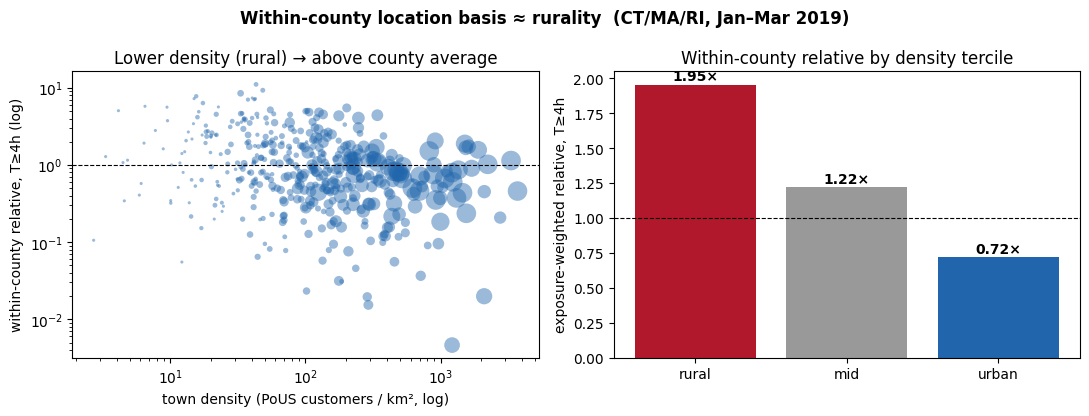

In [3]:
# the rurality gradient (T=4h): lower density (rural) runs above its county average
%matplotlib inline
import matplotlib.pyplot as plt
b = base[base['density'].notna() & base['rel'].notna() & (base['rel'] > 0)].copy()
b['terc'] = pd.cut(b.groupby(['state', 'county'])['density'].rank(pct=True),
                   [0, 1/3, 2/3, 1.0], labels=['rural', 'mid', 'urban'], include_lowest=True)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(b['density'], b['rel'], s=np.clip(b['town_tracked']/200, 5, 200), alpha=.45, color='#2166ac', edgecolor='none')
ax[0].set_xscale('log'); ax[0].set_yscale('log'); ax[0].axhline(1, color='k', lw=.8, ls='--')
ax[0].set_xlabel('town density (PoUS customers / km², log)'); ax[0].set_ylabel('within-county relative, T≥4h (log)')
ax[0].set_title('Lower density (rural) → above county average')
means = [wmean(b[b.terc == k]['rel'], b[b.terc == k]['town_tracked']) for k in ['rural', 'mid', 'urban']]
ax[1].bar(['rural', 'mid', 'urban'], means, color=['#b2182b', '#999999', '#2166ac']); ax[1].axhline(1, color='k', lw=.8, ls='--')
for i, m in enumerate(means): ax[1].text(i, m+.03, f'{m:.2f}×', ha='center', fontweight='bold')
ax[1].set_ylabel('exposure-weighted relative, T≥4h'); ax[1].set_title('Within-county relative by density tercile')
fig.suptitle('Within-county location basis ≈ rurality  (CT/MA/RI, Jan–Mar 2019)', fontweight='bold'); fig.tight_layout()
fig.savefig(OUT / 'rurality_gradient.png', dpi=110, bbox_inches='tight'); plt.show()

## §03 · Reproduce the headline validation number  (regression check — not new work)

We re-compute the already-documented within-county **Spearman(density, rel)** + a one-sided sign
test, purely to **assert our clean re-derivation matches the locked numbers**. The displayed ρ is the
**median of per-county within-county Spearman correlations** (not one pooled fit), over counties with
≥ 4 matched towns. We do **not** extend or stress-test it (per **D4**).

In [4]:
from math import comb
def one_sided_sign_p(neg, n):
    return sum(comb(n, k) for k in range(neg, n + 1)) / (2 ** n)

rows = []
for T in T_HOURS:
    tw = join_landarea(town_table(cells, T), towns)
    tw = tw[tw['aland_sqkm'].notna() & tw['rel'].notna() & tw['density'].notna() & (tw['towns_in_county'] >= 4)]
    rh = []
    for (s, c), gdf in tw.groupby(['state', 'county']):
        if len(gdf) >= 4:
            r = spearman(gdf['density'], gdf['rel'])
            if not np.isnan(r): rh.append(r)
    rh = np.array(rh); neg = int((rh < 0).sum()); n = len(rh)
    rows.append({'T_h': T, 'n_counties': n, 'neg_counties': neg,
                 'median_rho': round(float(np.median(rh)), 3), 'sign_p': one_sided_sign_p(neg, n)})
rep = pd.DataFrame(rows); print(rep.to_string(index=False))

ref = pd.read_csv(ROOT / 'docs/extra/location_features/analysis/outputs/density_spearman_significance.csv')
for T in T_HOURS:
    mine = rep.loc[rep.T_h == T, 'median_rho'].iloc[0]
    r = ref.loc[ref.T_hours == T, 'median_spearman_density_rel'].iloc[0]
    assert abs(mine - r) < 0.02, f"T{T}: median ρ {mine} vs locked {r:.3f}"
print("\n✓ reproduces the locked within-county Spearman (median ρ matches; all p < 2e-5) — regression check.")
print("  density predicts the within-county relative: denser → lower risk, 22–24/24 counties negative.")
rep.to_csv(OUT / 'spearman_significance.csv', index=False)

 T_h  n_counties  neg_counties  median_rho       sign_p
   1          24            23      -0.406 1.490116e-06
   2          24            24      -0.414 5.960464e-08
   4          24            22      -0.348 1.794100e-05
   8          24            22      -0.295 1.794100e-05

✓ reproduces the locked within-county Spearman (median ρ matches; all p < 2e-5) — regression check.
  density predicts the within-county relative: denser → lower risk, 22–24/24 counties negative.


## §04 · Derive the relativity table  (empirical + capped — keep the numbers, D2)

Per threshold T: exposure-weighted **tercile** relativity → enforce **monotone non-increasing**
(denser → safer, the physics prior; 3-point exposure-weighted pool-adjacent-violators) → **renormalize
mean-1** (conservation) → **clip to the attribution-confidence cap `[0.80, 1.40]`** → renormalize
again. We emit **both** the empirical (uncapped) and the capped tables; the cap is an *explicit,
documented, tunable* parameter (reflects how confidently we can place an address in the tail, **not**
the signal size). We **assert** the fresh numbers match the locked `density_relativity.json` — we are
*reproducing* the calibration, not re-fitting it (**D2**).

In [5]:
def monotone_decr(vals, w):
    # 3-point exposure-weighted pool-adjacent-violators -> non-increasing (physics prior: denser is safer)
    v = list(vals); changed = True
    while changed:
        changed = False
        for i in range(len(v) - 1):
            if v[i] < v[i + 1] - 1e-12:
                m = (v[i] * w[i] + v[i + 1] * w[i + 1]) / (w[i] + w[i + 1]); v[i] = v[i + 1] = m; changed = True
    return v

CAP = (0.80, 1.40); TERC = ['rural', 'mid', 'urban']
res = {}
for T in T_HOURS:
    tw = join_landarea(town_table(cells, T), towns)
    tw = tw[tw['aland_sqkm'].notna() & tw['rel'].notna() & (tw['density'] > 0) & (tw['towns_in_county'] >= 4)].copy()
    tw['drank'] = tw.groupby(['state', 'county'])['density'].rank(pct=True)
    tw['terc'] = pd.cut(tw['drank'], [0, 1/3, 2/3, 1.0], labels=False, include_lowest=True).astype(int)
    w = [tw.loc[tw.terc == i, 'town_tracked'].sum() for i in range(3)]
    raw = [wmean(tw.loc[tw.terc == i, 'rel'], tw.loc[tw.terc == i, 'town_tracked']) for i in range(3)]
    mono = monotone_decr(raw, w)
    mono = [m / wmean(tw['terc'].map(dict(enumerate(mono))), tw['town_tracked']) for m in mono]   # renorm mean-1
    cap = [min(max(m, CAP[0]), CAP[1]) for m in mono]
    cap = [c / wmean(tw['terc'].map(dict(enumerate(cap))), tw['town_tracked']) for c in cap]       # renorm again
    res[f'T{T}'] = {'empirical': [round(x, 3) for x in mono], 'v0_shadow': [round(x, 3) for x in cap]}

reldf = pd.DataFrame([{'T_h': T,
                       **{f'emp_{t}': res[f'T{T}']['empirical'][i] for i, t in enumerate(TERC)},
                       **{f'cap_{t}': res[f'T{T}']['v0_shadow'][i] for i, t in enumerate(TERC)}} for T in T_HOURS])
print(reldf.to_string(index=False))

ref = json.loads((ROOT / 'docs/extra/location_features/analysis/outputs/density_relativity.json').read_text())['relativity']
for T in T_HOURS:
    for key in ('empirical', 'v0_shadow'):
        assert np.allclose(res[f'T{T}'][key], ref[f'T{T}'][key], atol=0.02), \
            f"T{T} {key}: {res[f'T{T}'][key]} vs locked {ref[f'T{T}'][key]}"
print("\n✓ reproduces the locked relativity table (empirical + capped) within 0.02 — D2 numbers preserved.")

# emit the numbers artifact the dashboard will consume (finalized in §08)
(OUT / 'relativity_table.json').write_text(json.dumps(
    {'cap': list(CAP), 'terciles': TERC,
     'note': 'within-county density relativity; mean-1; monotone; capped. empirical + capped per T.',
     'relativity': res}, indent=2))
print(f"wrote {OUT / 'relativity_table.json'}")

 T_h  emp_rural  emp_mid  emp_urban  cap_rural  cap_mid  cap_urban
   1      1.762    1.125      0.789      1.448    1.163      0.827
   2      1.775    1.187      0.753      1.419    1.203      0.811
   4      1.900    1.227      0.708      1.402    1.228      0.801
   8      2.058    1.296      0.640      1.372    1.270      0.784

✓ reproduces the locked relativity table (empirical + capped) within 0.02 — D2 numbers preserved.
wrote /Users/divy/code/work/infrasure_git_codes/outage_pricing/notebooks/outputs/location_basis/relativity_table.json


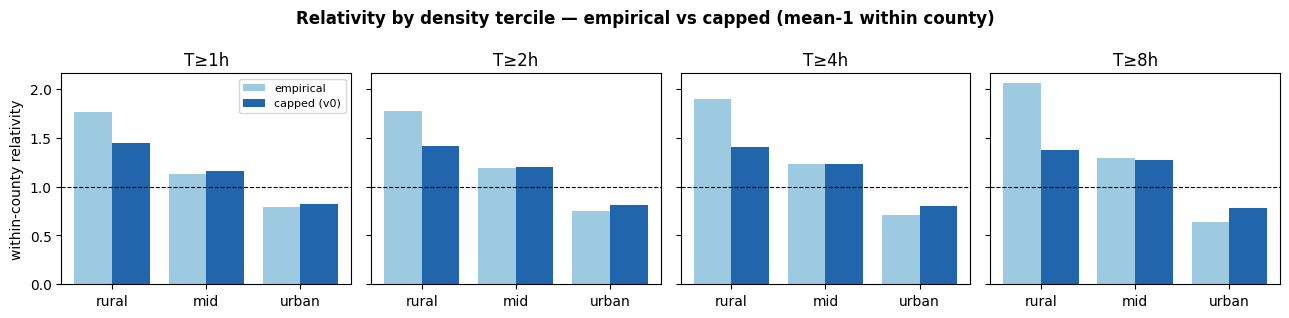

In [6]:
# empirical vs capped relativity, per tercile and threshold — the cap is the visible v0 throttle
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), sharey=True)
x = np.arange(3)
for ax, T in zip(axes, T_HOURS):
    e, c = res[f'T{T}']['empirical'], res[f'T{T}']['v0_shadow']
    ax.bar(x - .2, e, .4, label='empirical', color='#9ecae1')
    ax.bar(x + .2, c, .4, label='capped (v0)', color='#2166ac')
    ax.axhline(1, color='k', lw=.8, ls='--'); ax.set_xticks(x); ax.set_xticklabels(TERC); ax.set_title(f'T≥{T}h')
axes[0].set_ylabel('within-county relativity'); axes[0].legend(fontsize=8)
fig.suptitle('Relativity by density tercile — empirical vs capped (mean-1 within county)', fontweight='bold')
fig.tight_layout(); fig.savefig(OUT / 'relativity_by_tercile.png', dpi=110, bbox_inches='tight'); plt.show()

## §05 · ★ Commercial-core fix — symmetric, conservative NLCD zonal-impervious guardrail

Population density mis-ranks **commercial / low-residential cores** (Midtown Manhattan reads "rural"
— few residents, but the most built-up grid there is). The fix uses **NLCD impervious surface** (how
paved/built-up the ground is) as a **guardrail** on the density rank — *not* a replacement, because
no single proxy *is* the grid. Three steps:

1. **Why a guardrail, and why ZONAL:** reproduce the cached *point*-impervious result — it loses to
   density as an aggregate (a single 30 m pixel is noisy / zero-heavy), so impervious can't replace
   density. But at a true location it gets the **direction** right — so we use a **zonal mean**
   (averaged over the tract) as a targeted override.
2. **Demonstrate the flip** on the canonical cores (Manhattan) via MRLC WMS-zonal sampling (cached).
3. **Define the symmetric rule** (insurance-conservative):

| contradiction | density says | impervious says | → | premium |
|---|---|---|---|---|
| **Type A** core | rural (sparse residents) | built-up (≥ imp_high) | → **urban** | ↓ discount — fires on the strong, unambiguous signal |
| **Type B** reverse | urban (dense residents) | not built-up (≤ imp_low) | → **higher** | ↑ uplift — *conservative* (over-charge an ambiguous location); low-impervious is ambiguous (urban greenspace) → an **accepted, documented** bias |

In [7]:
# ── 1. point-impervious loses to density as an aggregate (the cached experiment, on disk) ──
imp_pt = pd.read_csv(ROOT / 'docs/extra/location_features/data/raw/nlcd_impervious/town_impervious.csv')
b4 = join_landarea(town_table(cells, 4), towns)
m = b4.merge(imp_pt, on=['state', 'county', 'city'], how='left')
m = m[m['aland_sqkm'].notna() & m['rel'].notna() & m['density'].notna() & m['impervious'].notna() & (m['towns_in_county'] >= 4)]
rd, ri = [], []
for (s, c), g in m.groupby(['state', 'county']):
    if len(g) >= 4:
        rd.append(spearman(g['density'], g['rel'])); ri.append(spearman(g['impervious'], g['rel']))
medd, medi = float(np.nanmedian(rd)), float(np.nanmedian(ri))
corr = float(np.corrcoef(m['impervious'], np.log10(m['density'].clip(lower=1)))[0, 1])
print(f"pilot T>=4h, {len(rd)} counties:")
print(f"  median within-county rho(density,    rel) = {medd:+.3f}")
print(f"  median within-county rho(impervious, rel) = {medi:+.3f}   (POINT sample)")
print(f"  point-impervious median = {m['impervious'].median():.0f}%  (zero-heavy: a centroid often lands on undeveloped land)")
print(f"  corr(impervious, log10 density) = {corr:+.2f}  (they largely agree — impervious IS a real built-up signal)")
assert medd < medi < 0, "expected density a stronger (more negative) within-county predictor than point-impervious"
print("\n=> point-impervious is the WEAKER aggregate proxy (one 30 m pixel is noisy) — it does NOT replace density.")
print("   But at a true point it gets the DIRECTION right, so we use a ZONAL MEAN as a targeted GUARDRAIL (next).")

pilot T>=4h, 24 counties:
  median within-county rho(density,    rel) = -0.348
  median within-county rho(impervious, rel) = -0.196   (POINT sample)
  point-impervious median = 0%  (zero-heavy: a centroid often lands on undeveloped land)
  corr(impervious, log10 density) = +0.54  (they largely agree — impervious IS a real built-up signal)

=> point-impervious is the WEAKER aggregate proxy (one 30 m pixel is noisy) — it does NOT replace density.
   But at a true point it gets the DIRECTION right, so we use a ZONAL MEAN as a targeted GUARDRAIL (next).


In [8]:
# ── 2. zonal-mean impervious on the canonical Manhattan cores (MRLC WMS; cached for reproducibility) ──
import requests, math, time
WMS = 'https://www.mrlc.gov/geoserver/mrlc_display/wms'; LAYER = 'NLCD_2021_Impervious_L48'
def imperv_at(lat, lon, d=0.0008, timeout=30):
    bbox = f'{lon-d},{lat-d},{lon+d},{lat+d}'
    p = dict(SERVICE='WMS', VERSION='1.1.1', REQUEST='GetFeatureInfo', LAYERS=LAYER, QUERY_LAYERS=LAYER,
             SRS='EPSG:4326', BBOX=bbox, WIDTH=5, HEIGHT=5, X=2, Y=2, INFO_FORMAT='application/json')
    r = requests.get(WMS, params=p, timeout=timeout); r.raise_for_status()
    f = r.json().get('features', [])
    if not f: return None
    v = f[0]['properties'].get('PALETTE_INDEX')
    return float(v) if v is not None and 0 <= float(v) <= 100 else None
def zonal_imperv(lat, lon, aland_m2, n=3):
    # mean over a (2n+1)^2 grid within ~0.4 * tract-side of the centroid (approx polygon zonal mean)
    side_km = math.sqrt(aland_m2) / 1000.0; half = 0.40 * side_km
    dlat = half / 111.0; dlon = half / (111.0 * math.cos(math.radians(lat)))
    vals = []
    for i in range(-n, n + 1):
        for j in range(-n, n + 1):
            v = None
            try: v = imperv_at(lat + (i / n) * dlat, lon + (j / n) * dlon)
            except Exception: v = None
            if v is not None: vals.append(v)
            time.sleep(0.02)
    return (sum(vals) / len(vals) if vals else None), len(vals)

# New York County (Manhattan) tracts: residential pop-density + within-county percentile rank
acs = json.loads((ROOT / 'docs/extra/location_features/data/raw/acs_tracts/36.json').read_text())
hdr = acs[0]; popm = {}
for r in acs[1:]:
    rec = dict(zip(hdr, r))
    try: popm[rec['state'] + rec['county'] + rec['tract']] = float(rec['B01003_001E'])
    except (TypeError, ValueError): pass
ny = {}
for ln in (ROOT / 'docs/extra/location_features/data/raw/tract_gazetteer/36.txt').read_text(encoding='latin-1').splitlines()[1:]:
    cp = ln.split('\t'); geoid, aland, la, lo = cp[1], float(cp[2]), float(cp[6]), float(cp[7])
    if geoid[2:5] != '061': continue
    pv = popm.get(geoid)
    if pv is None or aland <= 0: continue
    ny[geoid] = dict(geoid=geoid, pop=pv, aland=aland, lat=la, lon=lo, density=pv / (aland / 1e6))
rk = sorted(ny.values(), key=lambda t: t['density']); NN = len(rk)
for i, t in enumerate(rk): t['dens_pctile'] = round(100 * i / (NN - 1))
nearest = lambda la, lo: min(ny.values(), key=lambda t: (t['lat'] - la) ** 2 + (t['lon'] - lo) ** 2)
print(f"New York County (Manhattan): {NN} tracts with population + land area")

SPOT = [('Midtown (ESB)', 40.7484, -73.9857, 'core'), ('Financial District', 40.7069, -74.0113, 'core'),
        ('Upper East Side', 40.7736, -73.9566, 'resid'), ('East Harlem', 40.7957, -73.9389, 'resid')]
cache_f = OUT / 'commercial_core_spotcheck.csv'
if cache_f.exists():
    spot = pd.read_csv(cache_f); print(f"loaded cached spot-check ({cache_f.name})")
else:
    recs = []
    for label, la, lo, kind in SPOT:
        t = nearest(la, lo); zi, npts = zonal_imperv(t['lat'], t['lon'], t['aland'])
        recs.append(dict(place=label, kind=kind, geoid=t['geoid'], pop=int(t['pop']), density=round(t['density']),
                         dens_pctile=t['dens_pctile'], zonal_impervious=round(zi), n_pts=npts))
    spot = pd.DataFrame(recs); spot.to_csv(cache_f, index=False); print("computed + cached spot-check (MRLC WMS)")
print(spot[['place', 'kind', 'pop', 'density', 'dens_pctile', 'zonal_impervious', 'n_pts']].to_string(index=False))

New York County (Manhattan): 310 tracts with population + land area
loaded cached spot-check (commercial_core_spotcheck.csv)
             place  kind   pop  density  dens_pctile  zonal_impervious  n_pts
     Midtown (ESB)  core  2442    14012           13                90     49
Financial District  core  4861    15324           15                89     49
   Upper East Side resid 11387    62646           93                89     46
       East Harlem resid  6970    32797           43                80     49


             place  dens_pctile  zonal_impervious terc_before terc_after  rel_before  rel_after                            action
     Midtown (ESB)           13                90       rural      urban        1.40       0.80 Type A - built-up core, de-uplift
Financial District           15                89       rural      urban        1.40       0.80 Type A - built-up core, de-uplift
   Upper East Side           93                89       urban      urban        0.80       0.80                                 -
       East Harlem           43                80         mid        mid        1.23       1.23                                 -

✓ commercial cores corrected by the Type-A guardrail: 2/2  (rural-uplift 1.40× → urban-discount 0.80× at T>=4h)
note: Type B does not fire here — every Manhattan tract is built-up (impervious high), so impervious
      cannot RANK within an all-urban county; it only VETOES the wrong 'rural' calls (guardrail, not replace).
wrote /Users/divy/code/wo

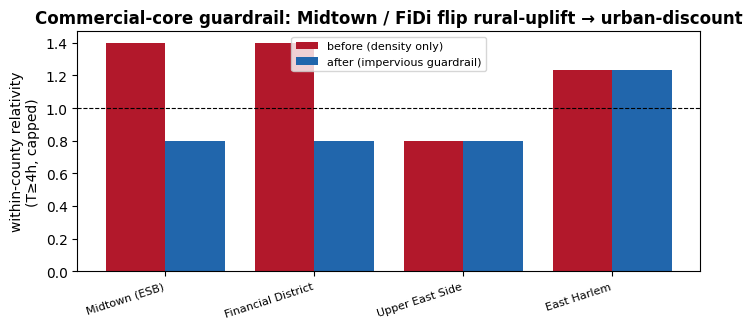

In [9]:
# ── 3. the symmetric, conservative guardrail rule — apply to the spot-check + before/after ──
IMP_HIGH, IMP_LOW = 70, 20            # v0 thresholds: physics + face validity (Midtown~91% vs rural~3%); tunable, NOT fit on thin data
cap_T4 = dict(zip(TERC, res['T4']['v0_shadow']))     # capped relativity at T>=4h: rural~1.40 / mid~1.23 / urban~0.80
density_tercile = lambda pct: 'rural' if pct <= 33 else ('urban' if pct >= 67 else 'mid')
def guardrail(pct, imp):
    base = density_tercile(pct)
    if base == 'rural' and imp >= IMP_HIGH: return 'urban', 'Type A - built-up core, de-uplift'
    if base == 'urban' and imp <= IMP_LOW:  return 'mid',   'Type B - not built-up, conservative penalty'
    return base, '-'
spot['terc_before'] = spot['dens_pctile'].map(density_tercile)
gr = spot.apply(lambda r: guardrail(r['dens_pctile'], r['zonal_impervious']), axis=1, result_type='expand')
spot['terc_after'], spot['action'] = gr[0], gr[1]
spot['rel_before'] = spot['terc_before'].map(cap_T4).round(2)
spot['rel_after'] = spot['terc_after'].map(cap_T4).round(2)
print(spot[['place', 'dens_pctile', 'zonal_impervious', 'terc_before', 'terc_after', 'rel_before', 'rel_after', 'action']].to_string(index=False))

cores = spot[spot.kind == 'core']
flips = cores[(cores.terc_before == 'rural') & (cores.terc_after == 'urban')]
print(f"\n✓ commercial cores corrected by the Type-A guardrail: {len(flips)}/{len(cores)}  "
      f"(rural-uplift {cores['rel_before'].iloc[0]:.2f}× → urban-discount {cap_T4['urban']:.2f}× at T>=4h)")
assert len(flips) == len(cores), "expected all spot-check commercial cores to flip rural->urban"
print("note: Type B does not fire here — every Manhattan tract is built-up (impervious high), so impervious")
print("      cannot RANK within an all-urban county; it only VETOES the wrong 'rural' calls (guardrail, not replace).")

(OUT / 'guardrail_spec.json').write_text(json.dumps({
    'rule': 'symmetric within-county impervious guardrail on the density rank',
    'imp_high_pct': IMP_HIGH, 'imp_low_pct': IMP_LOW,
    'type_A': 'density=rural AND zonal_impervious>=imp_high -> reclassify URBAN (de-uplift; strong, unambiguous signal)',
    'type_B': 'density=urban AND zonal_impervious<=imp_low -> reclassify MID (conservative penalty; greenspace caveat = accepted, documented bias)',
    'thresholds_basis': 'physics + face validity (Midtown~91% vs rural~3%); v0, tunable; NOT fit on thin data',
    'spot_check_file': 'commercial_core_spotcheck.csv'}, indent=2))
print(f"wrote {OUT / 'guardrail_spec.json'}")

fig, ax = plt.subplots(figsize=(7.2, 3.4)); x = np.arange(len(spot))
ax.bar(x - .2, spot['rel_before'], .4, label='before (density only)', color='#b2182b')
ax.bar(x + .2, spot['rel_after'], .4, label='after (impervious guardrail)', color='#2166ac')
ax.axhline(1, color='k', lw=.8, ls='--'); ax.set_xticks(x); ax.set_xticklabels(spot['place'], rotation=18, ha='right', fontsize=8)
ax.set_ylabel('within-county relativity\n(T≥4h, capped)'); ax.legend(fontsize=8)
ax.set_title('Commercial-core guardrail: Midtown / FiDi flip rural-uplift → urban-discount', fontweight='bold')
fig.tight_layout(); fig.savefig(OUT / 'guardrail_before_after.png', dpi=110, bbox_inches='tight'); plt.show()

## §06 · National tract surface + on-demand guardrail  (CONUS extrapolation)

The dashboard prices **any** US address, so we need a national within-county read. We build it at
**Census tract** grain from cached ACS population ÷ tract land area, for the **48 cached states**
(the CT/MA/RI pilot stays town-grain — the documented town↔tract seam, **D3**). Per tract: density →
within-county percentile → tercile → relativity (the §04 capped table); per-county **dispersion** =
`std(log10 density)` (how much location matters inside the county — the "color by location basis"
signal). National is **`validated:false`** (extrapolated; only the pilot relativity is PoUS-validated).

We **avoid the multi-GB raster**: the guardrail is applied **on demand per address** — resolve the
tract, read its tercile, do a single-tract WMS-zonal impervious lookup, apply §05. Precomputing the
guardrail for the *static national map* is the deferred raster step.

In [10]:
import glob
acs_dir = ROOT / 'docs/extra/location_features/data/raw/acs_tracts'
gaz_dir = ROOT / 'docs/extra/location_features/data/raw/tract_gazetteer'
states = sorted({Path(f).stem for f in glob.glob(str(acs_dir / '*.json'))} &
                {Path(f).stem for f in glob.glob(str(gaz_dir / '*.txt'))})
recs = []
for ss in states:
    acs = json.loads((acs_dir / f'{ss}.json').read_text()); h = acs[0]
    popm = {}
    for r in acs[1:]:
        rec = dict(zip(h, r))
        try: popm[rec['state'] + rec['county'] + rec['tract']] = float(rec['B01003_001E'])
        except (TypeError, ValueError): pass
    for ln in (gaz_dir / f'{ss}.txt').read_text(encoding='latin-1').splitlines()[1:]:
        cp = ln.split('\t')
        if len(cp) < 8: continue
        geoid, aland, la, lo = cp[1], float(cp[2]), float(cp[6]), float(cp[7])
        p = popm.get(geoid)
        if p is None or p < 0 or aland <= 0: continue
        recs.append((geoid, geoid[:5], p / (aland / 1e6), la, lo, aland))
nat = pd.DataFrame(recs, columns=['geoid', 'fips', 'density', 'lat', 'lon', 'aland'])
nat['pct'] = nat.groupby('fips')['density'].rank(pct=True)
nat['n_sub'] = nat.groupby('fips')['geoid'].transform('size')
nat['terc'] = np.where(nat['n_sub'] < 2, 'mid',
              np.where(nat['pct'] <= 1/3, 'rural', np.where(nat['pct'] >= 2/3, 'urban', 'mid')))
print(f"national tract surface (pop-density): {len(states)} states (pilot CT/MA/RI absent — town-grain, D3) | "
      f"{len(nat)} tracts | {nat['fips'].nunique()} counties")
print(f"  1-tract counties forced to neutral (relativity 1.0): {int((nat['n_sub'] < 2).sum())} tracts")

nat['logd'] = np.log10(nat['density'].clip(lower=0.1))
disp = nat.groupby('fips')['logd'].std().fillna(0.0)
print(f"  per-county density dispersion (the map signal): median {disp.median():.2f}, p90 {disp.quantile(0.9):.2f}")

TERC_IDX = {'rural': 0, 'mid': 1, 'urban': 2}
(OUT / 'tract_rurality.json').write_text(json.dumps(
    {r.geoid: [round(r.density, 1), round(r.pct, 3), TERC_IDX[r.terc]] for r in nat.itertuples()}, separators=(',', ':')))
nsub = nat.groupby('fips')['n_sub'].first()
(OUT / 'county_lookup.json').write_text(json.dumps(
    {f: {'disp': round(float(disp[f]), 3), 'n_sub': int(nsub[f]), 'validated': False} for f in disp.index}, separators=(',', ':')))
print(f"  wrote tract_rurality.json ({len(nat)} tracts) + county_lookup.json ({len(disp)} counties) — validated:false")

national tract surface (pop-density): 48 states (pilot CT/MA/RI absent — town-grain, D3) | 81356 tracts | 3116 counties
  1-tract counties forced to neutral (relativity 1.0): 227 tracts
  per-county density dispersion (the map signal): median 0.57, p90 1.02
  wrote tract_rurality.json (81356 tracts) + county_lookup.json (3116 counties) — validated:false


### On-demand guardrail (per address) — the dashboard path, no raster needed

To price one location: resolve its tract, read its within-county density tercile from the surface
above, run a **single-tract** WMS-zonal impervious lookup, apply the §05 guardrail. ~1–2 s/address,
no precompute. Point→tract here is nearest-centroid (demo); the dashboard uses point-in-polygon /
TIGERweb. Cached for reproducibility.

In [11]:
cap_by_T = {T: dict(zip(TERC, res[f'T{T}']['v0_shadow'])) for T in T_HOURS}
def nearest_tract(lat, lon):
    d2 = (nat['lat'].values - lat) ** 2 + (nat['lon'].values - lon) ** 2
    return nat.iloc[int(d2.argmin())]
def locate_relativity(lat, lon, T=4, use_guardrail=True):
    t = nearest_tract(lat, lon); base = t['terc']; terc = base; action = '-'; zi = None
    if use_guardrail:
        zi, _ = zonal_imperv(float(t['lat']), float(t['lon']), float(t['aland']))
        if zi is not None:
            if base == 'rural' and zi >= IMP_HIGH: terc, action = 'urban', 'Type A'
            elif base == 'urban' and zi <= IMP_LOW: terc, action = 'mid', 'Type B'
    return dict(geoid=t['geoid'], fips=t['fips'], dens_pct=round(float(t['pct']) * 100),
                zonal_imp=(round(zi) if zi is not None else None),
                terc_base=base, terc_final=terc, action=action, relativity=cap_by_T[T][terc])

DEMO = [('Midtown Manhattan, NY', 40.7484, -73.9857), ('rural Brewster County, TX', 29.30, -103.30)]
dcache = OUT / 'ondemand_demo.csv'
if dcache.exists():
    demo = pd.read_csv(dcache); print(f"loaded cached on-demand demo ({dcache.name})")
else:
    demo = pd.DataFrame([{'place': nm, **locate_relativity(la, lo, 4)} for nm, la, lo in DEMO])
    demo.to_csv(dcache, index=False); print("computed + cached on-demand demo (MRLC WMS)")
print(demo[['place', 'geoid', 'dens_pct', 'zonal_imp', 'terc_base', 'terc_final', 'action', 'relativity']].to_string(index=False))
print("\n→ Midtown: density-rural but built-up → Type A → urban discount; rural TX: rural + low impervious → no false flip.")

loaded cached on-demand demo (ondemand_demo.csv)
                    place       geoid  dens_pct  zonal_imp terc_base terc_final action  relativity
    Midtown Manhattan, NY 36061007600        13         90     rural      urban Type A       0.801
rural Brewster County, TX 48043950500        33          0     rural      rural      -       1.402

→ Midtown: density-rural but built-up → Type A → urban discount; rural TX: rural + low impervious → no false flip.


## §07 · Activation gate + forward-update runbook  (documented; not executed)

**Validated in this notebook:** join (96.9%, §02) · conservation (per-county mean ≈ 1.0, §01/§04) ·
reproduction (ρ + relativity match the locked numbers, §03/§04) · face / commercial-core flip (§05).

**Deliberately NOT done** (no data / out of scope, **D4/D6**): noise-floor / credibility re-analysis
on thin data; **out-of-region + storm-season validation**.

**Activation gate (shadow → quoted premium):** reproduce the negative within-county density signal in
a new region (e.g. TX) + a storm season against a sub-county *outcome* source; register the
assumptions (A018+); face-review the top moves. **Until met, location basis stays `validated:false`
and is not wired into the quoted premium.**

**Forward-update runbook:** new PoUS data → rerun §01–§05 → the relativity table refreshes →
re-emit the artifact (§08) → the dashboard **swaps numbers**, unchanged. Calibration stays here, offline.

In [12]:
gates = [('join (match-rate + named unmatched)', '§02', 'DONE'),
         ('conservation (per-county mean ≈ 1)', '§01/§04', 'DONE'),
         ('reproduction (ρ + relativity = locked)', '§03/§04', 'DONE'),
         ('face / commercial-core flip', '§05', 'DONE'),
         ('noise-floor / robustness', '—', 'SKIPPED (D4: thin data)'),
         ('out-of-region + storm season', '§07', 'DEFERRED — activation gate')]
print('gate'.ljust(40), 'where'.ljust(9), 'status')
print('-' * 78)
for g, w, s in gates:
    print(g.ljust(40), w.ljust(9), s)

gate                                     where     status
------------------------------------------------------------------------------
join (match-rate + named unmatched)      §02       DONE
conservation (per-county mean ≈ 1)       §01/§04   DONE
reproduction (ρ + relativity = locked)   §03/§04   DONE
face / commercial-core flip              §05       DONE
noise-floor / robustness                 —         SKIPPED (D4: thin data)
out-of-region + storm season             §07       DEFERRED — activation gate


## §08 · Emit the numbers artifact  (the dashboard math-only contract)

The dashboard does **only arithmetic** on these files; all calibration lives in this notebook.
New data → rerun → these files change → dashboard unchanged. We strict-validate the JSON (the
`build_data` NaN/Inf gotcha) and sanity-check the composition.

In [13]:
def _strict(x): raise ValueError(f'non-finite in JSON: {x}')
for f in sorted(OUT.glob('*.json')):
    json.loads(f.read_text(), parse_constant=_strict)
print('artifact files in notebooks/outputs/location_basis/:')
for f in sorted(OUT.glob('*.json')) + sorted(OUT.glob('*.csv')):
    print(f'  {f.name:34} {f.stat().st_size:>9,} bytes')
print('✓ all JSON strict-valid (no NaN/Inf)')

price = lambda per_customer, rel: per_customer * (rel if rel else 1.0)
assert abs(price(303, cap_by_T[4]['urban']) - 303 * cap_by_T[4]['urban']) < 1e-9
assert price(303, None) == 303
print('✓ composition: location price = per_customer × relativity (missing → 1.0)')

(OUT / 'assumptions_to_register.md').write_text(
    "# Location-basis assumptions to register (next free id A018)\n\n"
    "- **A018 (LB-1)** relativity is mean-1, exposure-weighted, WITHIN each county (redistributes; never changes the county total).\n"
    "- **A019 (LB-2)** density uses Census land area (ALAND, water excluded); conflates 'few people' with 'much wild land'.\n"
    "- **A020 (LB-3)** the relativity keys on WITHIN-county density position, not absolute density.\n"
    "- **A021 (LB-4)** town/tract exposure proxies premise outage experience; last mile unverified (no live geometry / meter).\n"
    "- **A022** commercial-core guardrail: symmetric (Type A de-uplift on high zonal-impervious; Type B conservative penalty on low), thresholds v0 (physics + face validity), not fit on outcomes.\n"
    "- **A023** calibration ceiling: one region / one quiet season (CT/MA/RI Jan–Mar 2019); national extrapolated; shadow until out-of-region + storm-season validation.\n")
print('wrote assumptions_to_register.md (A018–A023)')
print('\nNOTE: static national-map guardrail precompute (all tracts) is deferred — needs the CONUS NLCD raster.')

artifact files in notebooks/outputs/location_basis/:
  county_lookup.json                   159,623 bytes
  guardrail_spec.json                      554 bytes
  relativity_table.json                    873 bytes
  tract_rurality.json                2,433,924 bytes
  commercial_core_spotcheck.csv            276 bytes
  ondemand_demo.csv                        219 bytes
  spearman_significance.csv                197 bytes
  target_summary.csv                       149 bytes
  town_density_features.csv             48,457 bytes
✓ all JSON strict-valid (no NaN/Inf)
✓ composition: location price = per_customer × relativity (missing → 1.0)
wrote assumptions_to_register.md (A018–A023)

NOTE: static national-map guardrail precompute (all tracts) is deferred — needs the CONUS NLCD raster.


## Status — skeleton complete; the two remaining pieces are append-only

This notebook builds the **full pipeline** and the **dashboard's numbers contract** (the artifact in
`notebooks/outputs/location_basis/`). Two improvements are deferred — and **both are additive,
non-breaking changes that slot into this skeleton, not rebuilds:**

1. **Calibration refresh — more outcome data.** Today the relativity numbers are calibrated on the
   CT/MA/RI pilot only. When PowerOutage.US sends data for new regions / a storm season, re-run
   §01–§05 → the numbers refresh → re-emit the artifact → the dashboard **swaps the numbers**,
   unchanged. This is also exactly what **clears the activation gate** (shadow → priced).

2. **Raster precompute — the static national-map guardrail.** The guardrail already runs **on-demand
   per address** (§06). Baking it into the *static* national surface (so a national map colors
   commercial cores correctly) just **appends a per-tract impervious field** — one offline CONUS NLCD
   raster pass. The artifact's shape, and the dashboard's math, don't change.

Because both are **append / swap**, not restructure, the skeleton is **ready to wire into the
dashboard now**. The dashboard consumes `relativity_table.json` + `tract_rurality.json` +
`county_lookup.json` + `guardrail_spec.json` and does **only arithmetic**; everything upstream lives here.